# Data Preprocessing --ver2--

In [ ]:
### Dependencies ###
# Core
import numpy as np
import pandas as pd

# Viz
import seaborn as sns
import matplotlib.pyplot as plt

# setting
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.preprocessing.preprocessing import Preprocessing
from src.config import data_config

In [ ]:
pre = Preprocessing()
raw_data = pre._load()
df = pre.run()

In [3]:
raw_data.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2014-339,Brisbane,Hard,28,A,20131229,1,103813,NaN,NaN,...,29.0,23.0,6.0,8.0,2.0,5.0,39.0,1090.0,136.0,425.0
1,2014-339,Brisbane,Hard,28,A,20131229,2,104594,NaN,NaN,...,76.0,51.0,18.0,17.0,7.0,11.0,61.0,774.0,35.0,1160.0
2,2014-339,Brisbane,Hard,28,A,20131229,3,105023,NaN,NaN,...,40.0,26.0,12.0,11.0,6.0,9.0,46.0,960.0,29.0,1244.0
3,2014-339,Brisbane,Hard,28,A,20131229,4,105032,NaN,WC,...,59.0,43.0,15.0,12.0,4.0,4.0,172.0,307.0,100.0,549.0
4,2014-339,Brisbane,Hard,28,A,20131229,5,103917,NaN,NaN,...,50.0,43.0,12.0,14.0,2.0,4.0,50.0,918.0,70.0,697.0


In [5]:
df.head()

,elo_diff,elo_hard_diff,elo_clay_diff,elo_grass_diff,glicko2_diff,glicko2_hard_diff,glicko2_clay_diff,glicko2_grass_diff,rank_diff,rank_points_diff,age_diff,height_diff,surface,tourney_level,target
0,-161.966872,-103.213837,-102.998856,10.796981,-231.108821,-149.921555,-270.079622,-82.159865,97.0,-665.0,-10.5,-2.0,Hard,A,0
26,353.290879,349.632062,312.802805,462.708969,322.917895,303.717901,422.286201,702.071199,-55.0,3431.0,4.0,-9.0,Hard,A,1
25,75.798447,-2.945813,-61.646934,81.831296,99.508172,7.469975,-72.100093,155.149145,16.0,-257.0,5.1,3.0,Hard,A,0
24,-12.935327,-19.614745,50.390153,-38.989738,-25.474936,-36.951751,159.308911,11.647902,-32.0,530.0,-0.6,8.0,Hard,A,0
23,253.012496,181.909036,173.501626,80.072490,281.779354,239.611513,331.304783,197.034931,-128.0,1421.0,5.8,-8.0,Hard,A,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29162 entries, 0 to 29161
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   elo_diff            29162 non-null  float64
 1   elo_hard_diff       29162 non-null  float64
 2   elo_clay_diff       29162 non-null  float64
 3   elo_grass_diff      29162 non-null  float64
 4   glicko2_diff        29162 non-null  float64
 5   glicko2_hard_diff   29162 non-null  float64
 6   glicko2_clay_diff   29162 non-null  float64
 7   glicko2_grass_diff  29162 non-null  float64
 8   rank_diff           29162 non-null  float64
 9   rank_points_diff    29162 non-null  float64
 10  age_diff            29162 non-null  float64
 11  height_diff         29162 non-null  float64
 12  surface             29162 non-null  object 
 13  tourney_level       29162 non-null  object 
 14  target              29162 non-null  int32  
dtypes: float64(12), int32(1), object(2)
memory usage: 3.4+ MB


## Visualization

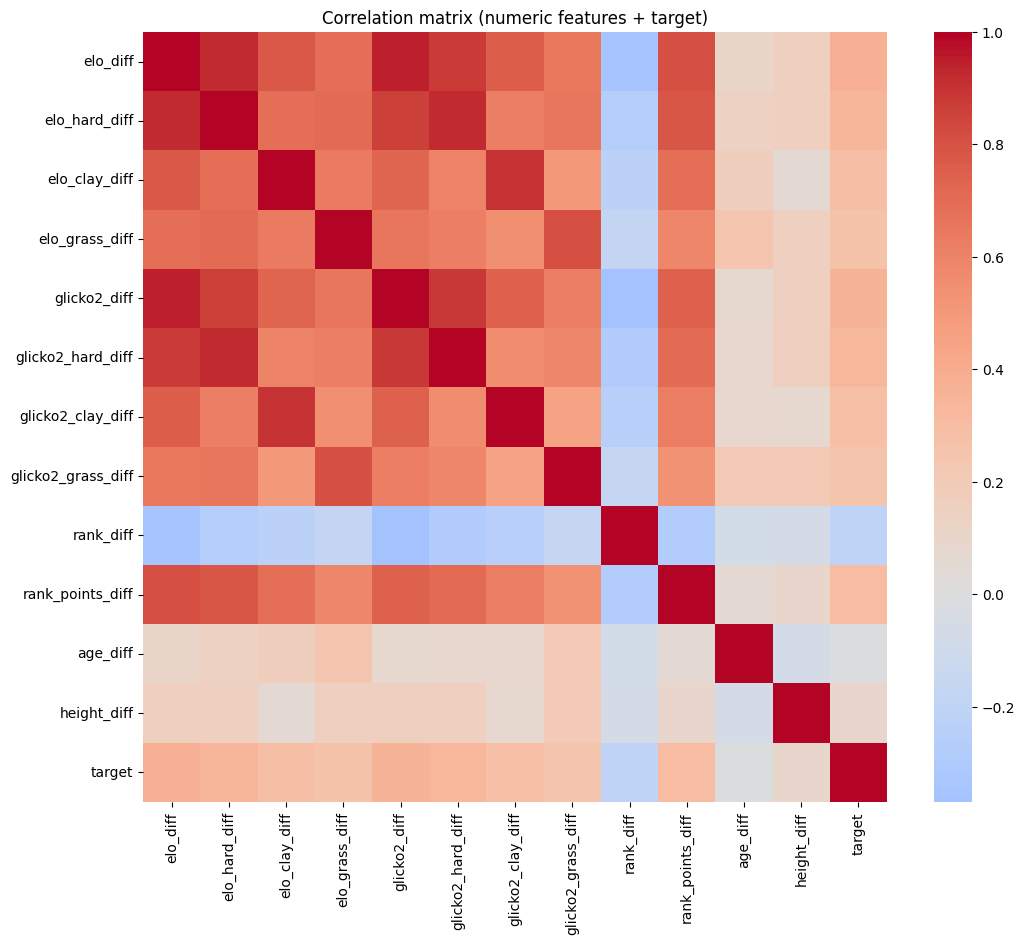

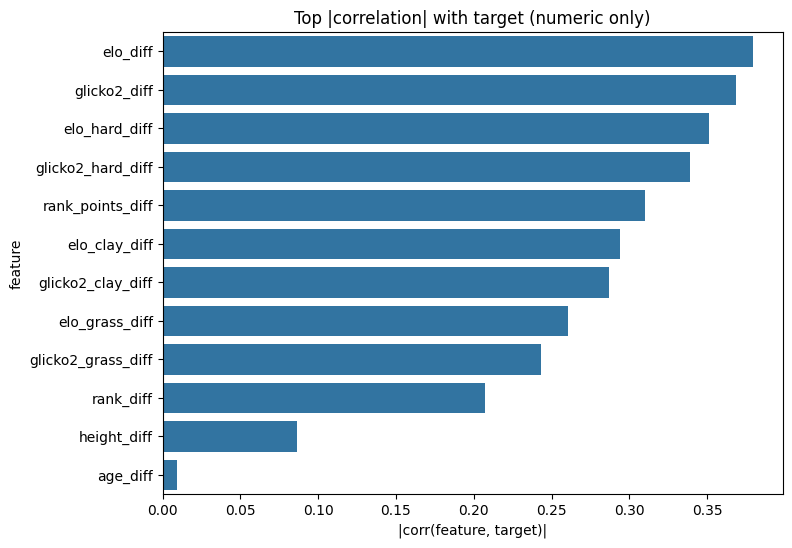

elo_diff              0.379603
glicko2_diff          0.368326
elo_hard_diff         0.351471
glicko2_hard_diff     0.339110
rank_points_diff      0.309952
elo_clay_diff         0.294092
glicko2_clay_diff     0.286815
elo_grass_diff        0.260453
glicko2_grass_diff    0.243250
rank_diff            -0.207456
height_diff           0.086470
age_diff             -0.009077
Name: target, dtype: float64

In [13]:

df = df.copy()

# Chỉ lấy cột numeric + target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "target" not in num_cols:
    num_cols.append("target")

corr = df[num_cols].corr(numeric_only=True)

# Heatmap (toàn bộ numeric)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Correlation matrix (numeric features + target)")
plt.show()

# Top correlation với target
corr_with_target = corr["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_with_target.abs().values[:15], y=corr_with_target.index[:15], orient="h")
plt.title("Top |correlation| with target (numeric only)")
plt.xlabel("|corr(feature, target)|")
plt.ylabel("feature")
plt.show()

corr_with_target.head(20)

# Data Preprocessing --ver1--
This dataset is ATP competition - tennis matches

Sources:
- https://github.com/JeffSackmann/tennis_atp
- https://www.tennisabstract.com/

`Hung Nguyen` data preprocessing: This work exists many bugs like: drop na rows instead of columns, there is no elo feature, ... `Quang To`'s work is better.

In [ ]:
### Dependency ###

# Core
from pathlib import Path
import numpy as np
import pandas as pd

# Viz
import seaborn as sns
import matplotlib.pyplot as plt

# Model


## Data understanding

In [ ]:
### Load data ###
DATA_DIR = Path("..") / "data"
matches_dir =  DATA_DIR / "matches" / "main" # main matches in ATP

years = range(2010, 2024 + 1)
files = [matches_dir / f"atp_matches_{year}.csv" for year in years]

df_matches = pd.concat((pd.read_csv(file) for file in files), ignore_index=True)
# convert "tourney_date": int --> date type
df_matches["tourney_date"] = pd.to_datetime(df_matches["tourney_date"], format="%Y%m%d", errors="coerce")


### Data infomation ##
row, column = df_matches.shape
print(f"ATP data: {row} rows, {column} columns")
df_matches.head()

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\matches\\main\\atp_matches_2010.csv'

In [ ]:
df_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42571 entries, 0 to 42570
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tourney_id          42571 non-null  object        
 1   tourney_name        42571 non-null  object        
 2   surface             42518 non-null  object        
 3   draw_size           42571 non-null  int64         
 4   tourney_level       42571 non-null  object        
 5   tourney_date        42571 non-null  datetime64[ns]
 6   match_num           42571 non-null  int64         
 7   winner_id           42571 non-null  int64         
 8   winner_seed         18166 non-null  float64       
 9   winner_entry        5668 non-null   object        
 10  winner_name         42571 non-null  object        
 11  winner_hand         42571 non-null  object        
 12  winner_ht           42080 non-null  float64       
 13  winner_ioc          42571 non-null  object    

In [ ]:
df_matches.describe()

,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
count,42571.000000,42571,42571.000000,42571.000000,18166.000000,42080.000000,42568.000000,42571.000000,10242.000000,41471.000000,...,39829.000000,39829.000000,39829.000000,39829.000000,39829.000000,39829.000000,42309.000000,42309.000000,41900.000000,41900.000000
mean,57.126729,2017-04-10 19:02:21.983979520,157.236945,116786.103850,7.547561,187.280822,27.107517,116756.718376,9.056532,186.467001,...,49.656205,33.296568,14.857842,12.429009,4.757689,8.518316,75.455600,1898.047035,112.968592,1117.472315
min,2.000000,2010-01-03 00:00:00,1.000000,100644.000000,1.000000,3.000000,14.900000,100644.000000,1.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,32.000000,2013-06-10 00:00:00,18.000000,104559.000000,3.000000,183.000000,24.100000,104571.000000,4.000000,183.000000,...,36.000000,23.000000,10.000000,9.000000,2.000000,6.000000,17.000000,666.000000,35.000000,525.000000
50%,32.000000,2017-02-13 00:00:00,148.000000,105227.000000,5.000000,188.000000,26.900000,105341.000000,7.000000,185.000000,...,46.000000,31.000000,14.000000,11.000000,4.000000,8.000000,44.000000,1030.000000,66.000000,786.000000
75%,96.000000,2021-05-10 00:00:00,281.000000,106421.000000,9.000000,191.000000,29.900000,106423.000000,12.000000,191.000000,...,60.000000,41.000000,19.000000,15.000000,7.000000,11.000000,83.000000,2030.000000,110.000000,1210.000000
max,128.000000,2024-12-18 00:00:00,1701.000000,212721.000000,33.000000,211.000000,44.600000,212970.000000,33.000000,211.000000,...,328.000000,284.000000,101.000000,91.000000,27.000000,38.000000,2101.000000,16950.000000,2159.000000,16950.000000
std,41.982609,NaN,150.380538,28824.454858,6.993900,7.329994,4.142929,28654.593482,7.548200,7.185836,...,19.410688,14.572636,7.100643,4.258443,3.264858,4.136493,130.276167,2322.907494,181.888598,1292.927201


### 1) Detailed column meanings

| Column | Typical dtype | Meaning / how it is recorded |
|---|---:|---|
| `tourney_id` | string | Tournament identifier (starts with year, rest varies by source). Useful for grouping, not as a numeric feature. |
| `tourney_name` | string/category | Tournament name (e.g., Brisbane, Wimbledon). High-cardinality categorical. |
| **`surface`** | category | Court surface: typically Hard / Clay / Grass / Carpet (older). |
| `draw_size` | int | Number of players in draw (often rounded to power of 2, e.g., 28 shown as 32). |
| `tourney_level` | category | Tournament tier code (ATP examples: `G` Grand Slam, `M` Masters 1000, `A` Tour, `C` Challenger, etc.). |
| `tourney_date` | datetime | Tournament week date, usually Monday, format `YYYYMMDD` in raw CSV. |
| `match_num` | int | Match identifier within tournament (not globally unique, sometimes arbitrary). |
| `winner_id` | int/string | Player id (from this repo) of the **winner**. |
| `winner_seed` | float/int | Seed number of the winner (missing if unseeded). |
| `winner_entry` | string/category | Entry code: `WC` wild card, `Q` qualifier, `LL` lucky loser, `PR` protected ranking, etc. |
| `winner_name` | string | Winner’s name (text label). |
| **`winner_hand`** | category | Serving hand: `R`, `L`, `U`. |
| **`winner_ht`** | float/int | Winner height (cm), may be missing. |
| `winner_ioc` | category | Winner country code (3 letters). |
| **`winner_age`** | float | Winner age in years at `tourney_date`. |
| `loser_id` | int/string | Player id (from this repo) of the **loser**. |
| `loser_seed` | float/int | Seed number of the loser (missing if unseeded). |
| `loser_entry` | string/category | Loser entry code (same code set as winner). |
| `loser_name` | string | Loser’s name. |
| **`loser_hand`** | category | Loser serving hand (`R`, `L`, `U`). |
| **`loser_ht`** | float/int | Loser height (cm). |
| `loser_ioc` | category | Loser country code (3 letters). |
| **`loser_age`** | float | Loser age in years at `tourney_date`. |
| **`score`** | string | Final score string (e.g., `7-6(5) 6-4`). Encodes the result. |
| `best_of` | int | Max sets: 3 or 5. |
| `round` | category | Round code (e.g., `R32`, `R16`, `QF`, `SF`, `F`). |
| `minutes` | float/int | Match duration in minutes (missing for many matches). |
| `w_ace` | float/int | Winner aces. |
| `w_df` | float/int | Winner double faults. |
| `w_svpt` | float/int | Winner total serve points. |
| `w_1stIn` | float/int | Winner first serves in. |
| `w_1stWon` | float/int | Winner first-serve points won. |
| `w_2ndWon` | float/int | Winner second-serve points won. |
| `w_SvGms` | float/int | Winner serve games. |
| `w_bpSaved` | float/int | Winner break points saved. |
| `w_bpFaced` | float/int | Winner break points faced. |
| `l_ace` | float/int | Loser aces. |
| `l_df` | float/int | Loser double faults. |
| `l_svpt` | float/int | Loser total serve points. |
| `l_1stIn` | float/int | Loser first serves in. |
| `l_1stWon` | float/int | Loser first-serve points won. |
| `l_2ndWon` | float/int | Loser second-serve points won. |
| `l_SvGms` | float/int | Loser serve games. |
| `l_bpSaved` | float/int | Loser break points saved. |
| `l_bpFaced` | float/int | Loser break points faced. |
| **`winner_rank`** | float/int | Winner rank as of `tourney_date` (or most recent ranking before). |
| **`winner_rank_points`** | float/int | Winner ranking points (when available). |
| **`loser_rank`** | float/int | Loser rank as of `tourney_date` (or most recent ranking before). |
| **`loser_rank_points`** | float/int | Loser ranking points (when available). |

---
### 2) Feature selection & data leakage

#### A) Task: predict the **match score** pre-match, while **NOT using player identity correlation**

Constraint: the model must NOT “remember” a specific player across matches. Treat every match as two generic players: `p1` and `p2`.

Because the raw data is labeled as `winner_*` and `loser_*`, the dataset must be  **re-frame** before modeling:
- Convert each match into `p1` vs `p2` (e.g., randomly assign winner/loser to p1/p2 for each row).
- Use `score` as the target `y` (or parse `score` into a numeric target such as total games, game difference, number of sets, etc.).
- Use only features that are available **before** the match starts.
##### Removal

**a) Drop due to data leakage**
- `score` (if predicting score, this is the label)
- `minutes`
- All post-match stats: every `w_*` and `l_*` column (aces, double faults, serve points, break points, etc.)

**b) Drop/avoid direct usage of `winner_*` / `loser_*` as features**
Columns named `winner_*` and `loser_*` are not valid *as-is* for any pre-match prediction, because they already assume the outcome.
- Do not feed `winner_rank`, `loser_rank`, … under winner/loser semantics.
- Re-map to `p1_*` and `p2_*` using a p1/p2 assignment that is independent of the outcome.

**c) Drop to respect the “no identity correlation” constraint**
These enable memorization of individual players:
- `winner_id`, `loser_id`, `winner_name`, `loser_name`
Also recommended to drop (ID-like columns):
- `tourney_id`, `match_num`
Optional / high-risk for overfitting:
- `tourney_name` (can make the model memorize tournaments; prefer `tourney_level`, `surface`, `draw_size`)

#### Chosen features

**a) Tournament / match context**
- `surface`, `draw_size`, `tourney_level`, `round`, `best_of`
- From `tourney_date`: `year`, `month`, `week`

**b) Player attributes available pre-match**
- Ranking strength at match time: `p1_rank`, `p2_rank`, `p1_rank_points`, `p2_rank_points`
- Seed/entry: `p1_seed`, `p2_seed`, `p1_entry`, `p2_entry`
- Bio: `p1_age`, `p2_age`, `p1_ht`, `p2_ht`, `p1_hand`, `p2_hand`
- Optional: `p1_ioc`, `p2_ioc` (may introduce bias; only keep if you accept it)

**c) New feature**
Prefer **difference / pairwise** features so the model learns relative strength instead of absolute values:
- `rank_diff = p1_rank - p2_rank`
- `points_diff = p1_rank_points - p2_rank_points`
- `age_diff`, `height_diff`, etc.

#### Common pitfalls
- Using `w_*` / `l_*` stats: these are computed after the match → leakage.
- Using `score` in features: 100% leakage.
- Using player IDs/names: violates the constraint and causes memorization.
- Random row splitting: can hide time-related distribution shift; prefer time-based split by `tourney_date` (train on earlier years, test on later years).

---

#### B) Identity-aware + time-aware setting: use player history to predict **win probability**
In this setting you **do** have time-ordered match history per player, and your goal changes to predicting a player’s **win/loss probability** for a given match. Here it is necessary to keep `player_id` and time information, because a player’s past performance is strongly predictive.

We still need to re-frame `winner_*` / `loser_*` into `p1/p2`, but now `p1` and `p2` are **real, persistent identities**:
- Keep `p1_id`, `p2_id` (derived from `winner_id/loser_id`)
- Define the label as $y=1$ if `p1` wins, else $y=0$
- Use a random swap (`p1`↔`p2`) per match so the model cannot rely on any fixed ordering
- Compute every historical feature for match time $t$ using only matches with date $< t$

##### Classification
Let $x_{i,t}$ be the feature vector summarizing player $i$ **before** match time $t$. A common approach is to predict win probability from the **difference** of two players’ features:
$$
\Delta x_t = x_{p1,t} - x_{p2,t}, \qquad \hat{p}_t = P(y_t=1 \mid \Delta x_t) = \sigma(w^\top \Delta x_t),
$$
where $\sigma(z)=\frac{1}{1+e^{-z}}$ is the sigmoid function.

##### Elo rating as a time-dynamic feature
Elo is an online rating that updates after each match. The expected probability that player 1 beats player 2 is:
$$
p = \frac{1}{1 + 10^{-\frac{R_1 - R_2}{400}}}.
$$
After the match, update ratings:
$$
R_1' = R_1 + K(S_1 - p), \qquad R_2' = R_2 + K(S_2 - (1-p)),
$$
where $S_1 \in \{0,1\}$ is the observed outcome for player 1 (1 if win, 0 if loss) and $K$ controls how fast ratings change.

Practical Elo feature choices:
- Overall Elo, and/or surface-specific Elo (Hard/Clay/Grass)
- Recent Elo trend: $\Delta R = R_t - R_{t-\tau}$ for a time window $\tau$
- Elo difference feature: $R_{p1,t} - R_{p2,t}$

##### Time-based / form features
All of these must be computed using matches strictly before time $t$:
- Rolling win-rate:
  $$
  \text{winrate}_{i,t}^{(N)} = \frac{1}{N}\sum_{k=1}^{N} S_{i,t-k}
  $$
  using the last $N$ matches of player $i$.
- Rolling averages of performance (if you use match stats, they are allowed only if you are predicting *future* and computed from *past* matches): e.g., mean aces per match in last $N$ matches.
- Recency / fatigue proxies: days since last match, matches played in last 14/30 days.
- Head-to-head (H2H) history up to time $t$: wins of `p1` vs `p2` (careful: can be sparse).
- Surface form: win-rate on the current surface in the last $N$ matches.

##### Select and Drop

**Keep:**
- Player identity: `p1_id`, `p2_id` (from `winner_id/loser_id`)
- Time features from `tourney_date` (and any derived time windows)
- Player strength at time $t$: rank/points (these are themselves time-dependent)
- Any historical aggregates computed from past matches only (Elo, rolling win-rate, trends)

**Drop:**
- Current-match `w_*` / `l_*`, `minutes`, and `score` (these are outcomes of the match you are trying to predict)

##### Evaluation to avoid time leakage
To avoid leakage through time, do **chronological** evaluation:
- Train on earlier dates, validate/test on later dates (walk-forward / expanding window).
- Never compute a feature for a match using information from matches on the same date **after** it, or from future dates.

## Problem directions

```text
Match prediction problem directions
|__ No player ID
|   |__ Time shuffled (random split)
|   |   |__ Single-label: Win/Loss
|   |   |__ Multi-label / multi-task: Win/Loss + other outcomes
|   |
|   |__ Time preserved (chronological split)
|       |__ Single-label: Win/Loss
|       |__ Multi-label / multi-task: Win/Loss + other outcomes
|
|__ Use player ID
    |__ Single-label: Win/Loss
    |__ Multi-label / multi-task: Win/Loss + other outcomes
```
**Examples of “other outcomes” for multi-label / multi-task**
- Score-derived targets: number of sets, total games, game difference, straight-sets vs 3/5 sets
- Match duration (`minutes`) as a separate regression label (only if predicting it pre-match)
- Aggregate post-match stats as separate labels (only if they are targets, not features)

---
## A) No player ID
**Single-label:** win/loss label
- y = 1 if p1 wins
- y = 0 if p2 wins

In [ ]:
df_A = df_matches.copy()
feature_cols = [
        "surface", "draw_size", "tourney_level", "round", "best_of", "tourney_date",
        "winner_rank", "winner_rank_points", "winner_hand", "winner_age", "winner_ht", "winner_ioc",
        "loser_rank", "loser_rank_points", "loser_hand", "loser_age", "loser_ht", "loser_ioc"]
label_col = ["score"]
df_A = df_A[feature_cols + label_col]
df_A = df_A.dropna() # drop NaN rows

### re-frame ###
# random swap p1 and p2
rng = np.random.default_rng(42)
swap = rng.random(len(df_A)) < 0.5  # True => p1 = loser, p2 = winner

df_A = pd.DataFrame({
    "surface": df_A["surface"].values,
    "draw_size": df_A["draw_size"].values,
    "tourney_level": df_A["tourney_level"].values,
    "round": df_A["round"].values,
    "best_of": df_A["best_of"].values,
    "tourney_date": df_A["tourney_date"].values,

    "p1_rank": np.where(swap, df_A["loser_rank"], df_A["winner_rank"]),
    "p1_rank_points": np.where(swap, df_A["loser_rank_points"], df_A["winner_rank_points"]),
    "p1_hand": np.where(swap, df_A["loser_hand"], df_A["winner_hand"]),
    "p1_age": np.where(swap, df_A["loser_age"], df_A["winner_age"]),
    "p1_ht": np.where(swap, df_A["loser_ht"], df_A["winner_ht"]),
    "p1_ioc": np.where(swap, df_A["loser_ioc"], df_A["winner_ioc"]),

    "p2_rank": np.where(swap, df_A["winner_rank"], df_A["loser_rank"]),
    "p2_rank_points": np.where(swap, df_A["winner_rank_points"], df_A["loser_rank_points"]),
    "p2_hand": np.where(swap, df_A["winner_hand"], df_A["loser_hand"]),
    "p2_age": np.where(swap, df_A["winner_age"], df_A["loser_age"]),
    "p2_ht": np.where(swap, df_A["winner_ht"], df_A["loser_ht"]),
    "p2_ioc": np.where(swap, df_A["winner_ioc"], df_A["loser_ioc"]),

    "label": (~swap).astype(int), # boolean to binary
})
df_A["rank_diff"] = df_A["p1_rank"] - df_A["p2_rank"]
df_A["rank_points_diff"] = df_A["p1_rank_points"] - df_A["p2_rank_points"]
df_A["age_diff"] = df_A["p1_age"] - df_A["p2_age"]
df_A["ht_diff"] = df_A["p1_ht"] - df_A["p2_ht"]

df_A.head()


,surface,draw_size,tourney_level,round,best_of,tourney_date,p1_rank,p1_rank_points,p1_hand,p1_age,...,p2_rank_points,p2_hand,p2_age,p2_ht,p2_ioc,label,rank_diff,rank_points_diff,age_diff,ht_diff
0,Hard,32,A,R32,3,2010-01-03,7.0,4410.0,R,27.3,...,598.0,R,30.3,183.0,AUS,1,-70.0,3812.0,-3.0,5.0
1,Hard,32,A,R32,3,2010-01-03,78.0,590.0,L,22.3,...,400.0,L,22.5,198.0,AUS,0,-56.0,190.0,-0.2,-8.0
2,Hard,32,A,R32,3,2010-01-03,52.0,850.0,R,23.5,...,568.0,L,28.4,185.0,FIN,1,-36.0,282.0,-4.9,0.0
3,Hard,32,A,R32,3,2010-01-03,285.0,151.0,R,22.1,...,1260.0,L,28.6,183.0,AUT,1,257.0,-1109.0,-6.5,5.0
4,Hard,32,A,R32,3,2010-01-03,251.0,179.0,R,21.4,...,1655.0,R,24.2,196.0,CZE,0,231.0,-1476.0,-2.8,-13.0


In [ ]:
df_A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41030 entries, 0 to 41029
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   surface           41030 non-null  object        
 1   draw_size         41030 non-null  int64         
 2   tourney_level     41030 non-null  object        
 3   round             41030 non-null  object        
 4   best_of           41030 non-null  int64         
 5   tourney_date      41030 non-null  datetime64[ns]
 6   p1_rank           41030 non-null  float64       
 7   p1_rank_points    41030 non-null  float64       
 8   p1_hand           41030 non-null  object        
 9   p1_age            41030 non-null  float64       
 10  p1_ht             41030 non-null  float64       
 11  p1_ioc            41030 non-null  object        
 12  p2_rank           41030 non-null  float64       
 13  p2_rank_points    41030 non-null  float64       
 14  p2_hand           4103

### Viz

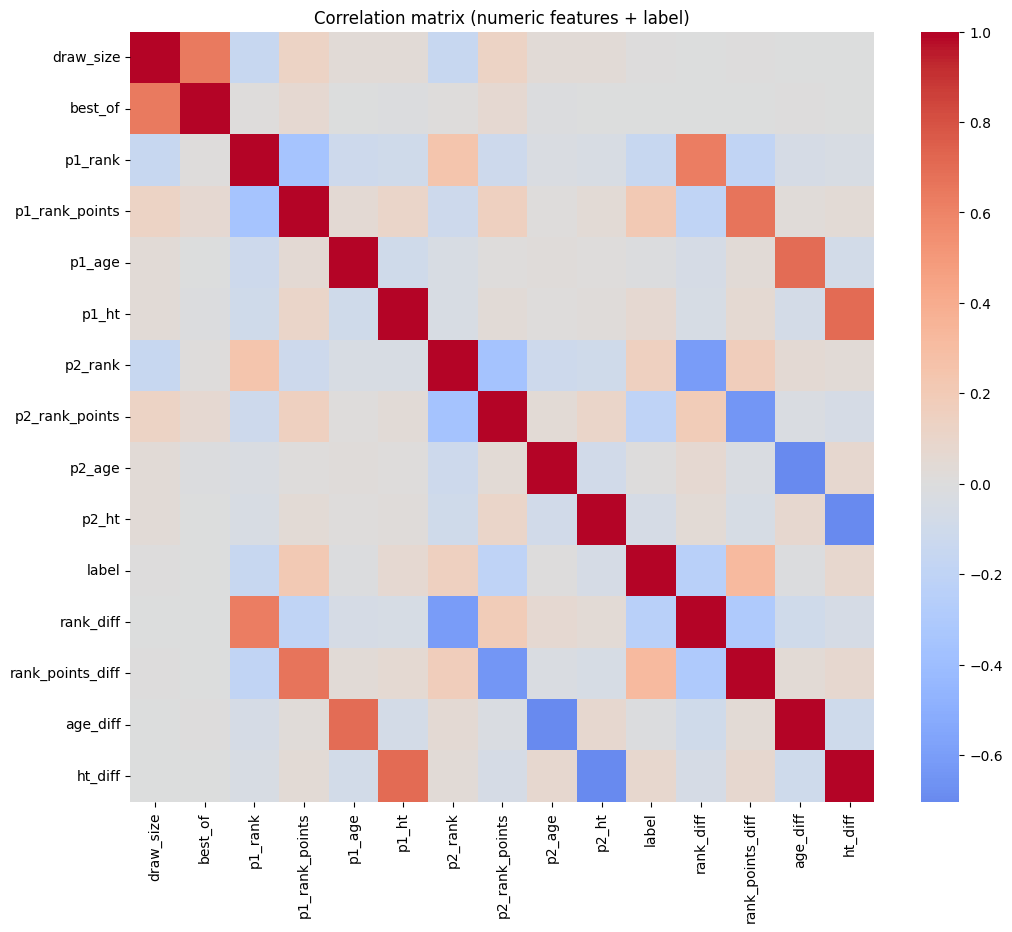

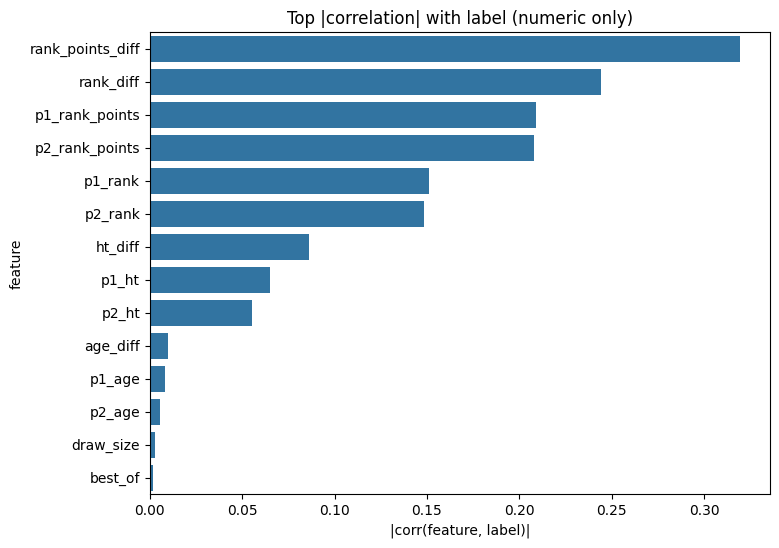

rank_points_diff    0.319684
rank_diff          -0.244179
p1_rank_points      0.208916
p2_rank_points     -0.207977
p1_rank            -0.151279
p2_rank             0.148535
ht_diff             0.086001
p1_ht               0.065090
p2_ht              -0.055340
age_diff           -0.009767
p1_age             -0.008058
p2_age              0.005631
draw_size           0.002645
best_of            -0.001938
Name: label, dtype: float64

In [ ]:

df = df_A.copy()

# Chỉ lấy cột numeric + label
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "label" not in num_cols:
    num_cols.append("label")

corr = df[num_cols].corr(numeric_only=True)

# Heatmap (toàn bộ numeric)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Correlation matrix (numeric features + label)")
plt.show()

# Top correlation với label
corr_with_label = corr["label"].drop("label").sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_with_label.abs().values[:15], y=corr_with_label.index[:15], orient="h")
plt.title("Top |correlation| with label (numeric only)")
plt.xlabel("|corr(feature, label)|")
plt.ylabel("feature")
plt.show()

corr_with_label.head(20)

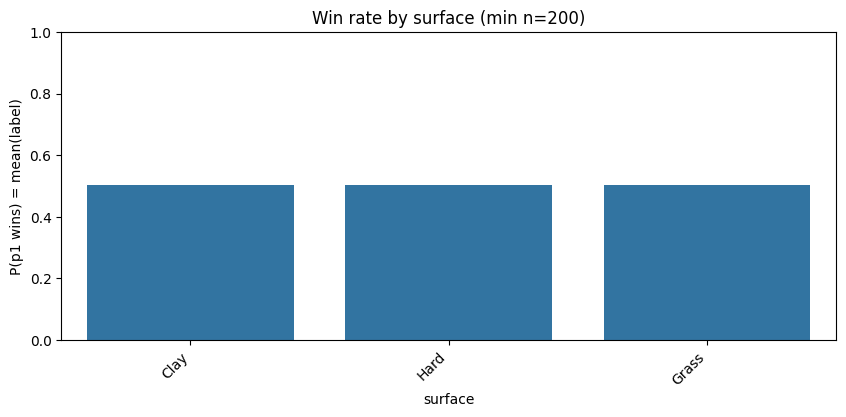

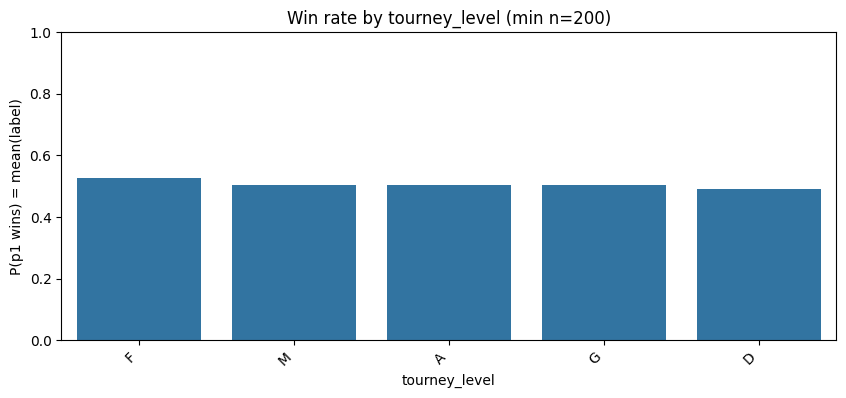

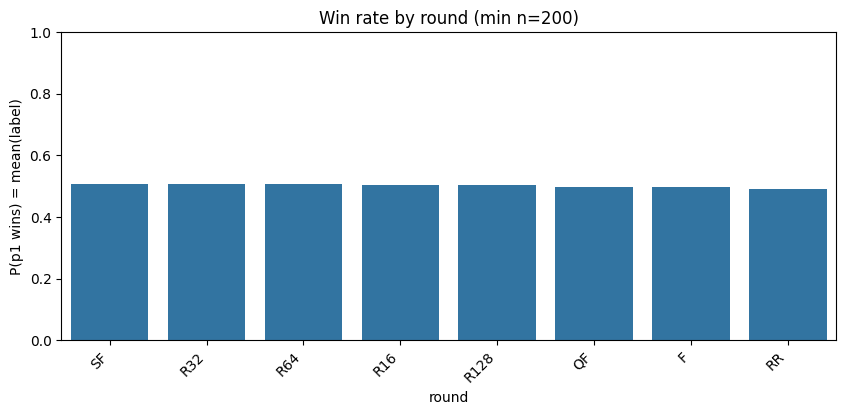

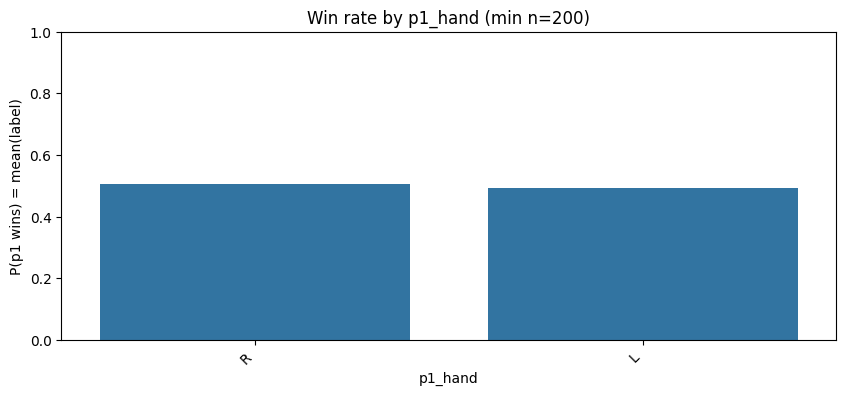

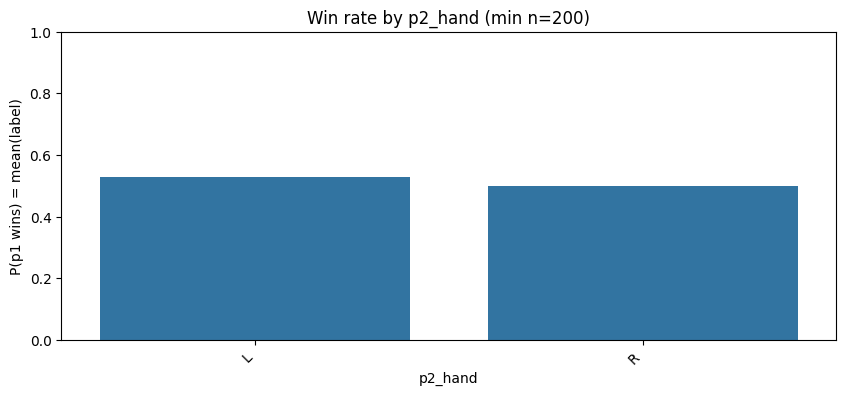

In [ ]:
df = df_A.copy()
cat_cols = ["surface", "tourney_level", "round", "p1_hand", "p2_hand"]

for c in cat_cols:
    tmp = (
        df.groupby(c)["label"]
        .agg(win_rate="mean", n="size")
        .reset_index()
        .sort_values("win_rate", ascending=False)
    )

    # lọc category quá ít mẫu để khỏi nhiễu
    tmp = tmp[tmp["n"] >= 200]

    plt.figure(figsize=(10, 4))
    sns.barplot(data=tmp, x=c, y="win_rate")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.title(f"Win rate by {c} (min n=200)")
    plt.ylabel("P(p1 wins) = mean(label)")
    plt.show()

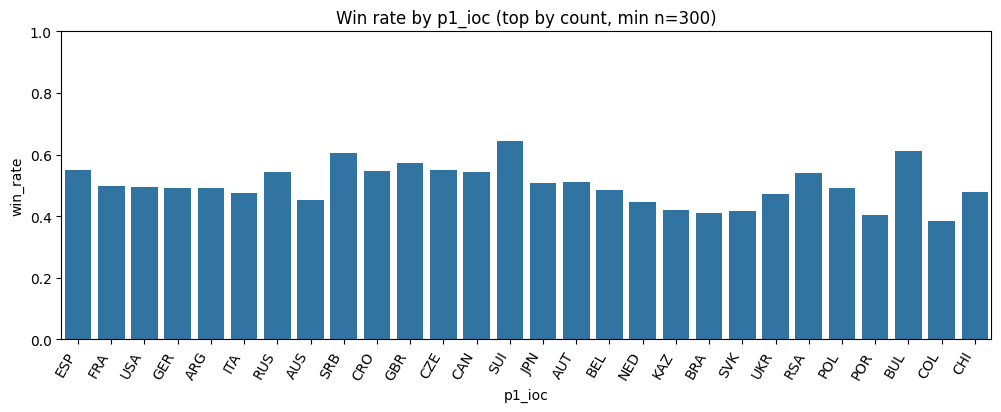

In [ ]:
c = "p1_ioc"
tmp = df.groupby(c)["label"].agg(win_rate="mean", n="size").reset_index()
tmp = tmp[tmp["n"] >= 300].sort_values("n", ascending=False).head(30)

plt.figure(figsize=(12, 4))
sns.barplot(data=tmp, x=c, y="win_rate")
plt.xticks(rotation=60, ha="right")
plt.ylim(0, 1)
plt.title("Win rate by p1_ioc (top by count, min n=300)")
plt.show()